In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from hmm_module import (
                create_transition_matrix, 
                simulate_c, 
                z_given_c_table, 
                simulate_z,
                simulate_x,
                simulate_hmm,
                plot_single,
                plot_freq,
                plot_all,
                plot_mean,
                make_datasets,
                x_given_z_vector,
                message_z_to_c,
                local_evidence_messages,
                forward_messages,
                backward_messages,
                posterior_c,
                posterior_z,
                hmm_pipeline,
                plot_c_posterior,
                plot_heatmap_z_posterior,
                plot_heatmap_z,
                lambda_hat_from_xz,
                alpha_hat_from_cz,
                beta_hat_from_C,
                gamma_hat_from_C,
                learn_all_params_from_known_data,
                hard_assigment_EM,
                init_lambda_kmeans,
                plot_convergence)

In [2]:
# suggested values
alpha_val = 0.9
beta_val = 0.2
small_gamma_val = 0.1
lambda_0 = 1
lambda_1 = 5

n = 10
big_T = 100

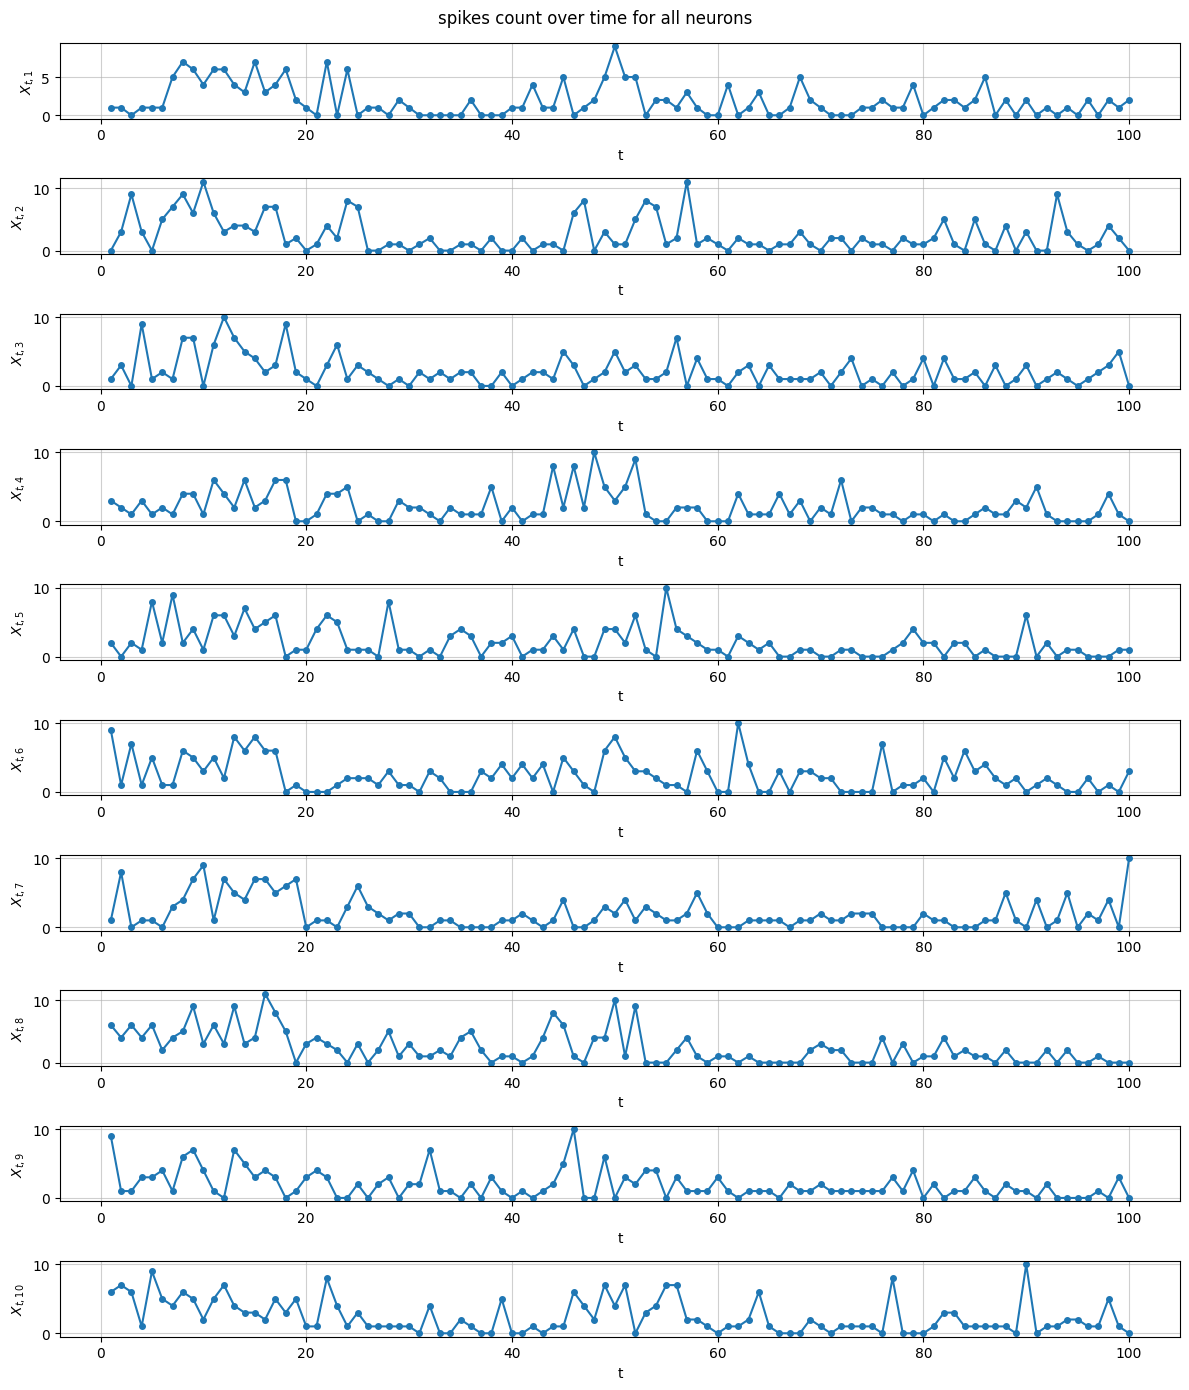

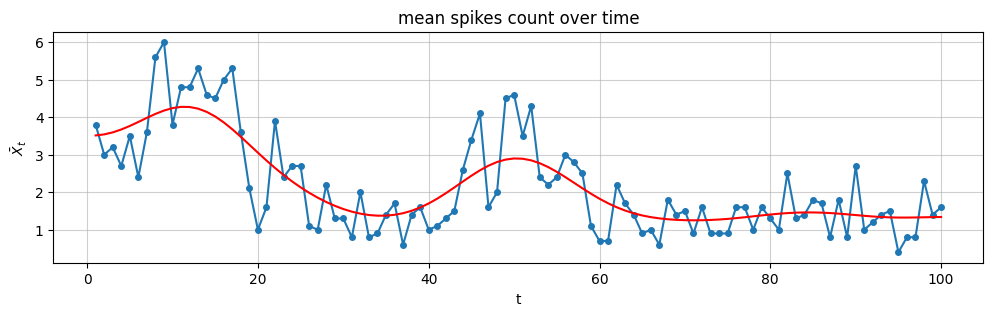

In [3]:
C, Z, X = simulate_hmm(big_T, n, alpha_val, beta_val, small_gamma_val, lambda_0, lambda_1)
plot_all(X)
plot_mean(X)

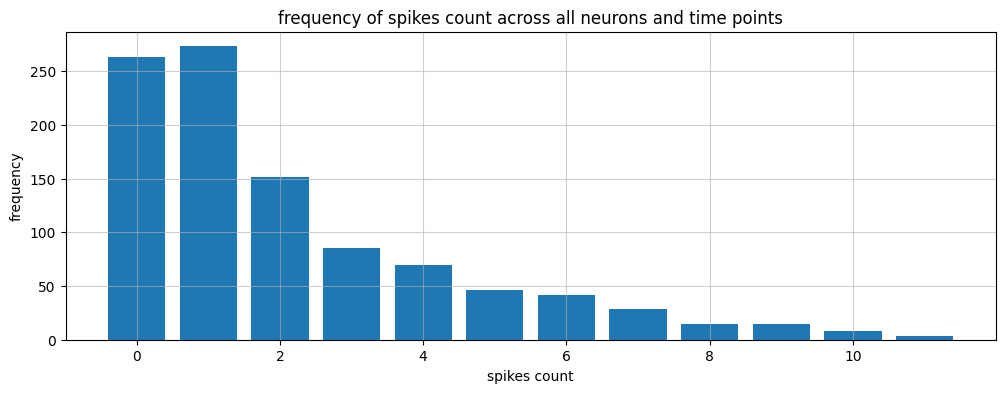

In [4]:
plot_freq(X)

In [5]:
x_features_data = []
y_labels_data = []

X_full_data = []
C_full_data = []
Z_full_data = []

t_indexes = [9, 19, 29, 39, 49, 59, 69, 79, 89, 99]
for t_idx in t_indexes:
    # with seed = 123 + t_idx, we get a different dataset for each t_index
    x_features, y_labels, X_full, C_full, Z_full = make_datasets(500, t_idx, big_T, n, alpha_val, beta_val,
                                                                 small_gamma_val, lambda_0, lambda_1, seed=123 + t_idx)
    x_features_data.append(x_features)
    y_labels_data.append(y_labels)
    X_full_data.append(X_full)
    C_full_data.append(C_full)
    Z_full_data.append(Z_full)
print(x_features_data[0].shape) # feature shape: (M, n)
print(y_labels_data[0].shape)   # labels shape: (M,)
print("class counts:", np.bincount(y_labels_data[0], minlength=3))

(500, 10)
(500,)
class counts: [163 149 188]


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x_train_data = []
x_test_data = []
y_train_data = []
y_test_data = []

X_full_train_data = []
X_full_test_data = []
C_full_train_data = []
C_full_test_data = []
Z_full_train_data = []
Z_full_test_data = []


for i in range(len(t_indexes)):
    x_train, x_test, y_train, y_test, X_full_train, X_full_test, C_full_train, C_full_test, Z_full_train, Z_full_test = train_test_split(
        x_features_data[i], y_labels_data[i], X_full_data[i], C_full_data[i], Z_full_data[i], test_size=0.2, random_state=123)

    x_train_data.append(x_train)
    x_test_data.append(x_test)
    y_train_data.append(y_train)
    y_test_data.append(y_test)

    X_full_train_data.append(X_full_train)
    X_full_test_data.append(X_full_test)
    C_full_train_data.append(C_full_train)
    C_full_test_data.append(C_full_test)
    Z_full_train_data.append(Z_full_train)
    Z_full_test_data.append(Z_full_test)

models = []
train_errors = []
test_errors = []

for i in range(len(t_indexes)):
    model = LogisticRegression(max_iter=5000, random_state=123)
    model.fit(x_train_data[i], y_train_data[i])
    
    train_errors.append(1 - model.score(x_train_data[i], y_train_data[i]))
    test_errors.append(1 - model.score(x_test_data[i], y_test_data[i]))
    models.append(model)

for i in range(len(t_indexes)):
    print(f"t={t_indexes[i]+1}: train_error={train_errors[i]:.6f}, test_error={test_errors[i]:.6f}")

t=10: train_error=0.200000, test_error=0.190000
t=20: train_error=0.175000, test_error=0.220000
t=30: train_error=0.180000, test_error=0.180000
t=40: train_error=0.175000, test_error=0.180000
t=50: train_error=0.157500, test_error=0.210000
t=60: train_error=0.182500, test_error=0.170000
t=70: train_error=0.160000, test_error=0.180000
t=80: train_error=0.175000, test_error=0.180000
t=90: train_error=0.165000, test_error=0.200000
t=100: train_error=0.182500, test_error=0.090000


In [7]:
C_true, Z_true, X_sim = simulate_hmm(big_T, n, alpha_val, beta_val, small_gamma_val, lambda_0, lambda_1, seed=123)

res_sim = hmm_pipeline(X_sim, alpha_val, beta_val, small_gamma_val, lambda_0, lambda_1)

C accuracy: 0.94
Z accuracy: 0.921


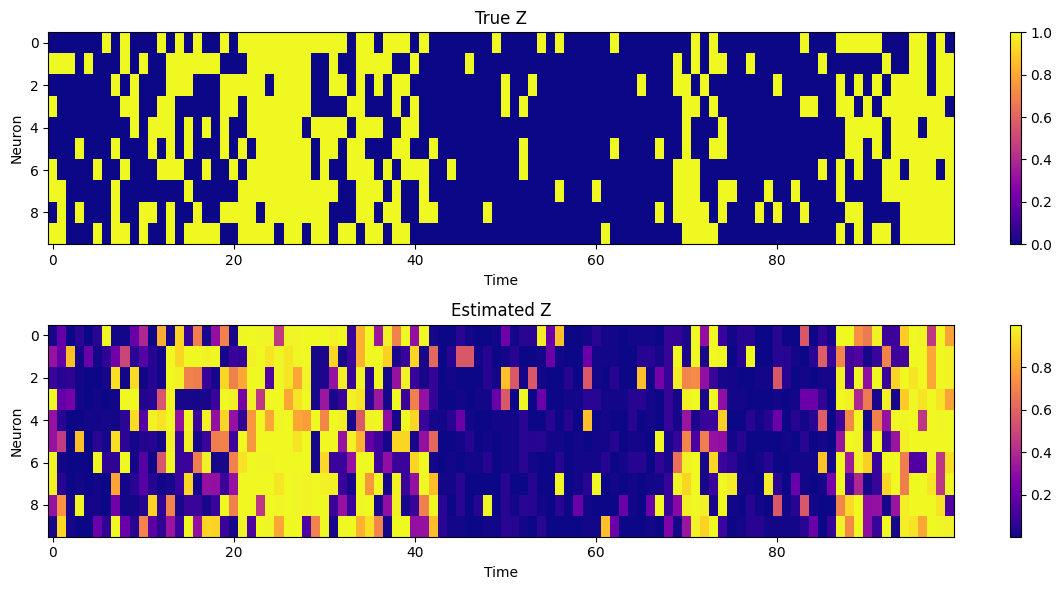

In [8]:
print("C accuracy:", np.mean(res_sim["c_hat"] == C_true))
print("Z accuracy:", np.mean(res_sim["z_hat"] == Z_true))

plot_heatmap_z(Z_true, res_sim["qZ"])

In [9]:
qC = res_sim["qC"]

for c in range(3):
    residual = (C_true == c) - qC[:, c]
    print(f"mean residual for C={c}: {np.mean(residual)}")

mean residual for C=0: -0.010398995100272548
mean residual for C=1: -0.023040313728088044
mean residual for C=2: 0.03343930882836059


In [10]:
qZ = res_sim["qZ"]
residual_z = Z_true - qZ
print("mean residual for Z=1:", np.mean(residual_z))

mean residual for Z=1: 0.006250087707369568


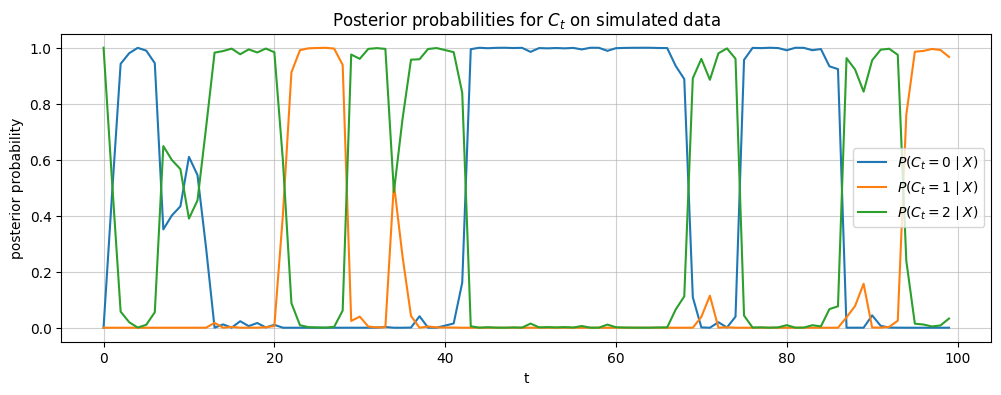

In [11]:
plot_c_posterior(res_sim)

In [12]:
all_data = ["proj_HMM/Ex_1.csv", "proj_HMM/Ex_2.csv", "proj_HMM/Ex_3.csv", "proj_HMM/Ex_4.csv", "proj_HMM/Ex_5.csv", "proj_HMM/Ex_6.csv", "proj_HMM/Ex_7.csv", "proj_HMM/Ex_8.csv", "proj_HMM/Ex_9.csv", "proj_HMM/Ex_10.csv"]

read_data = []

for i in all_data:
    df = pd.read_csv(i)
    df.drop(columns=["t"], axis=1, inplace=True)
    df = df.to_numpy()
    read_data.append(df)

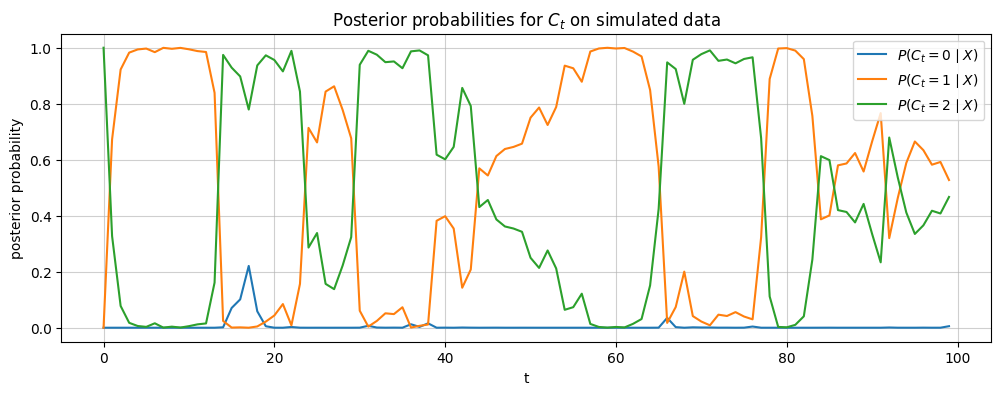

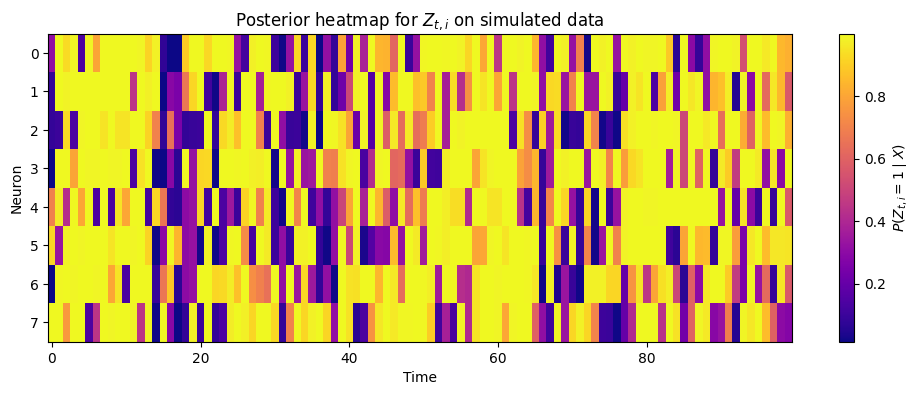

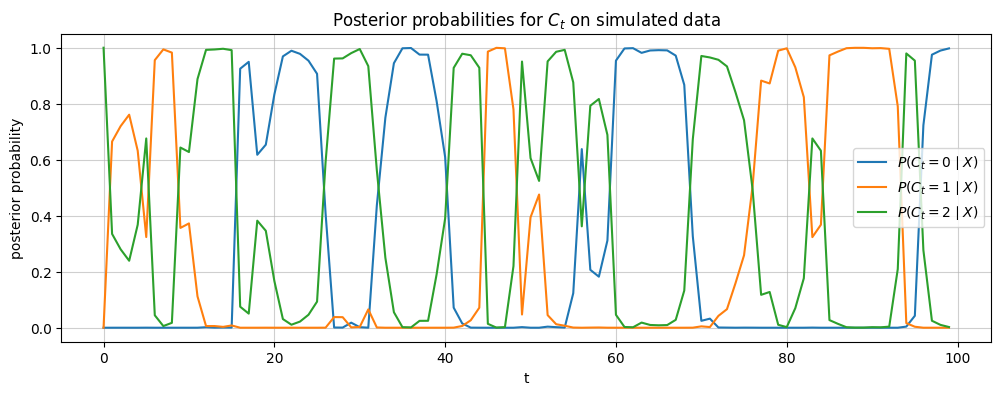

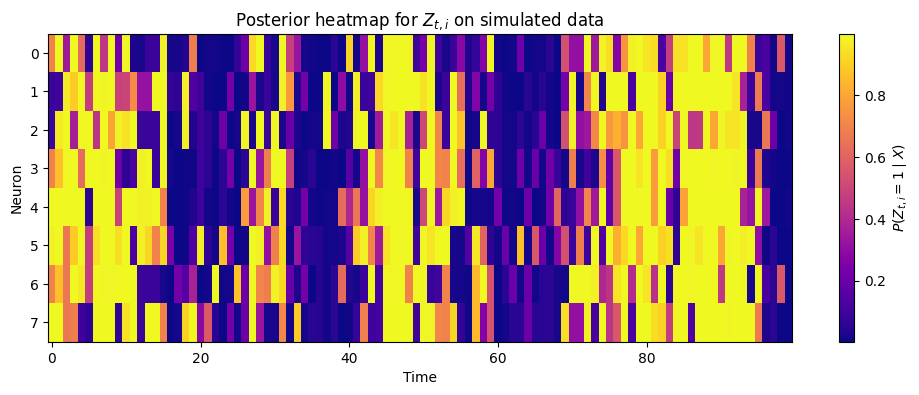

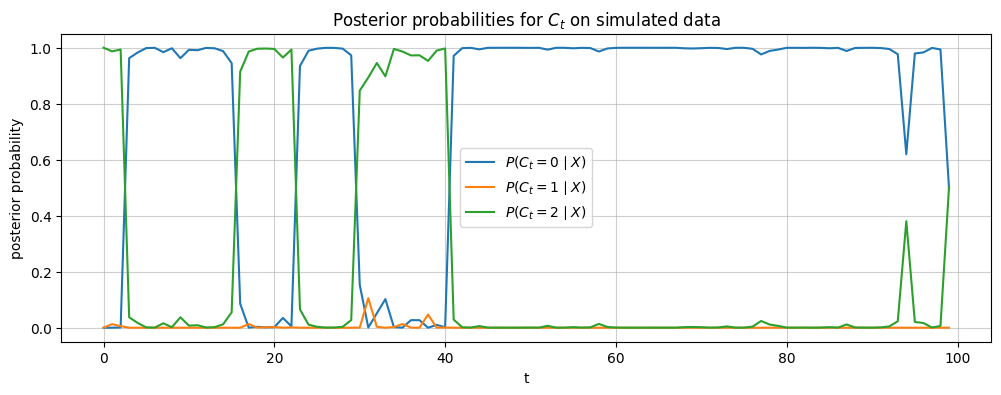

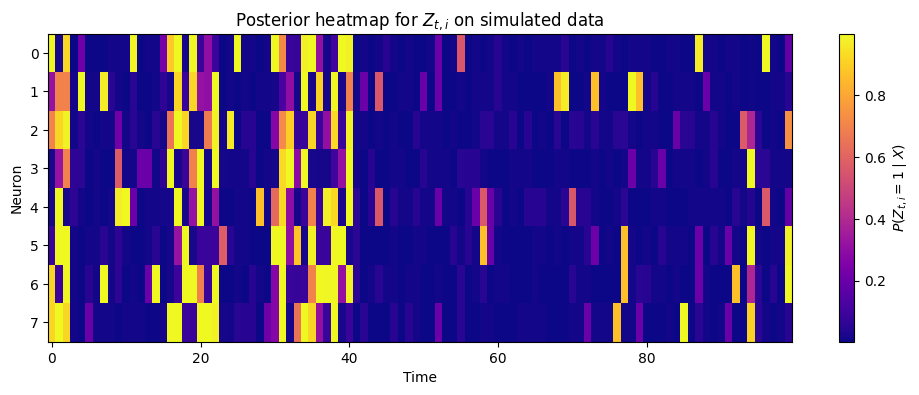

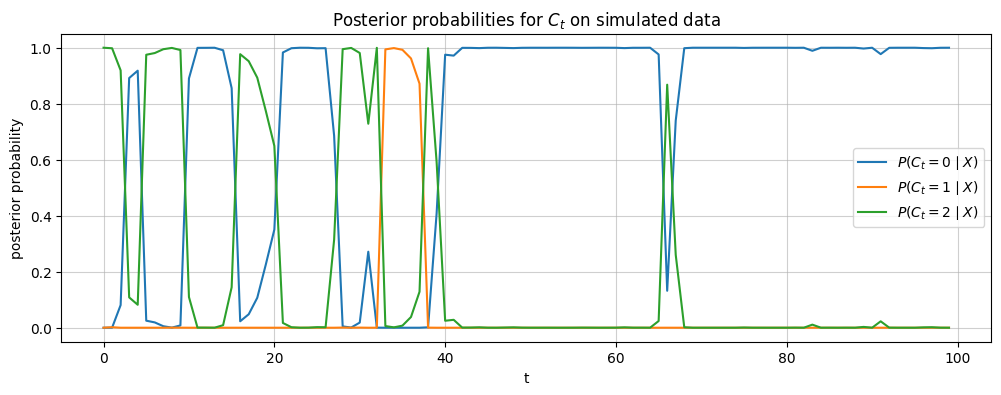

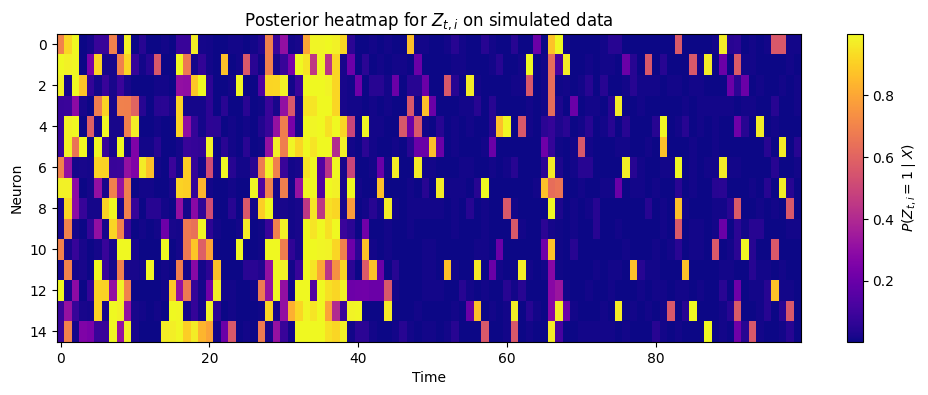

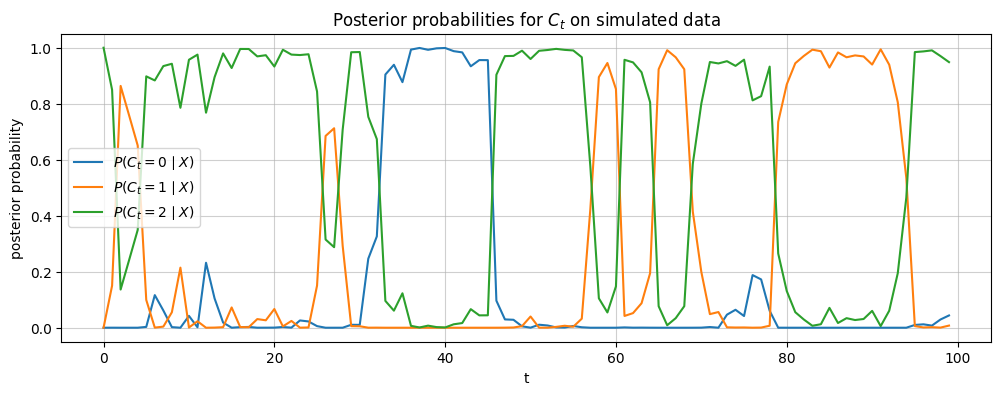

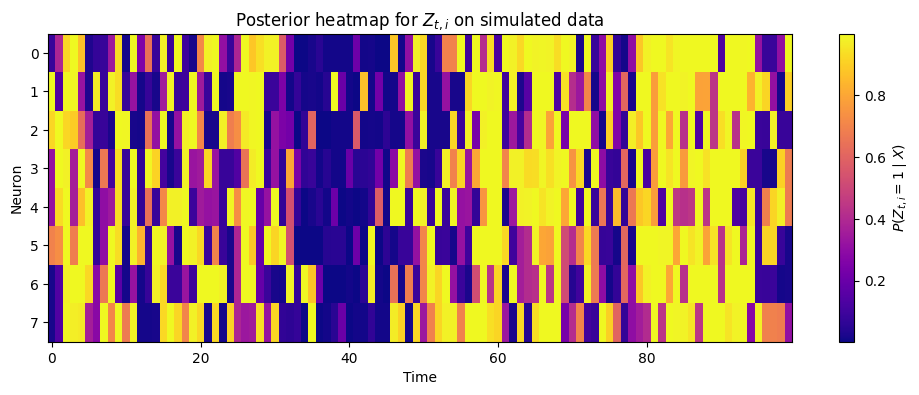

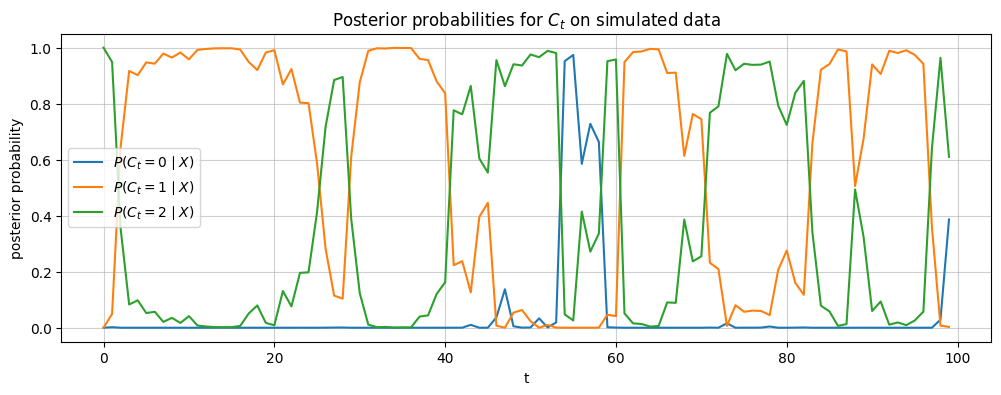

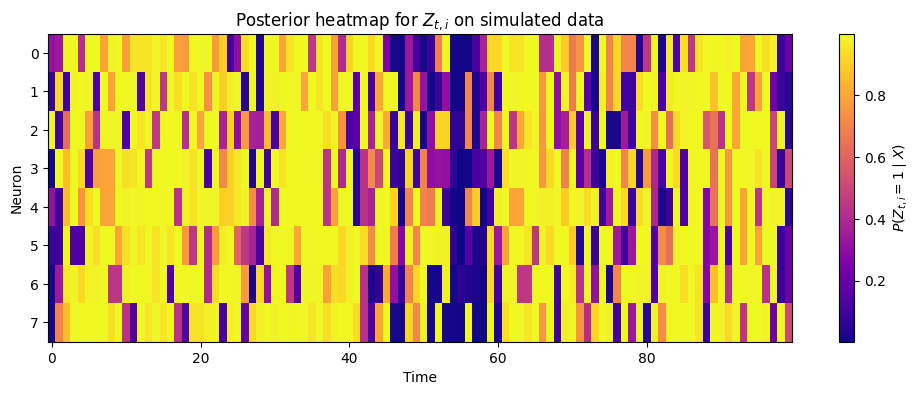

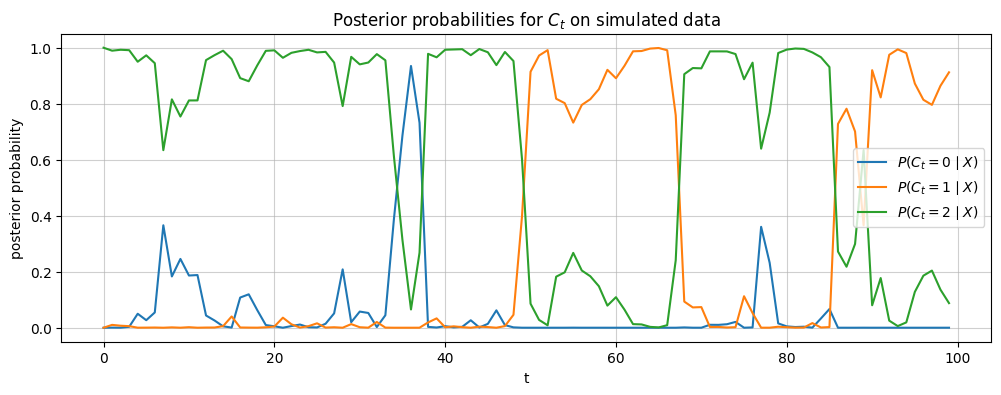

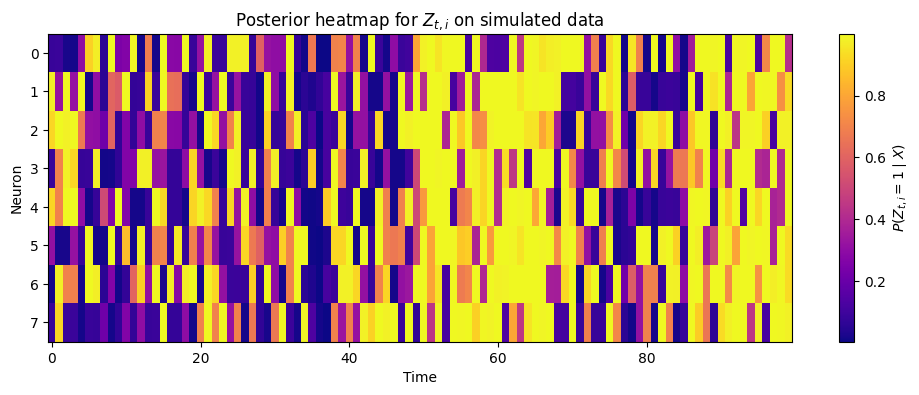

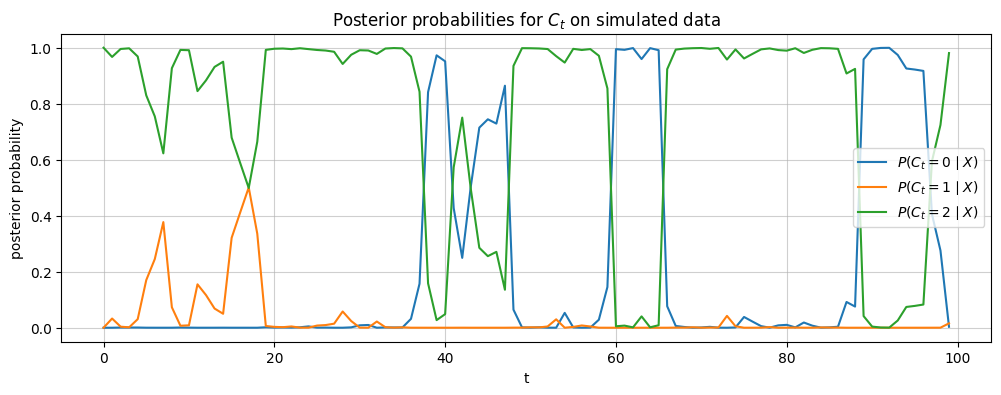

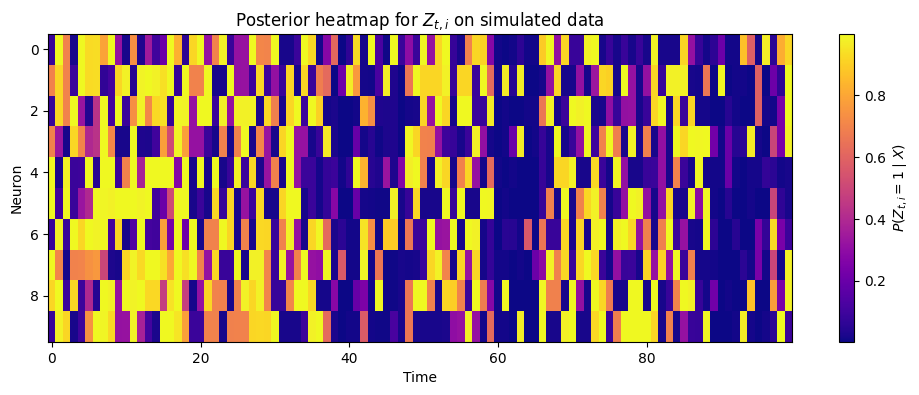

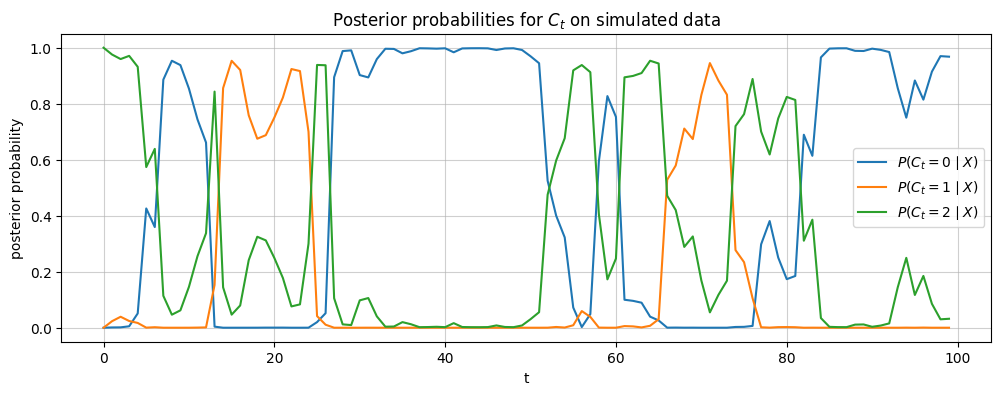

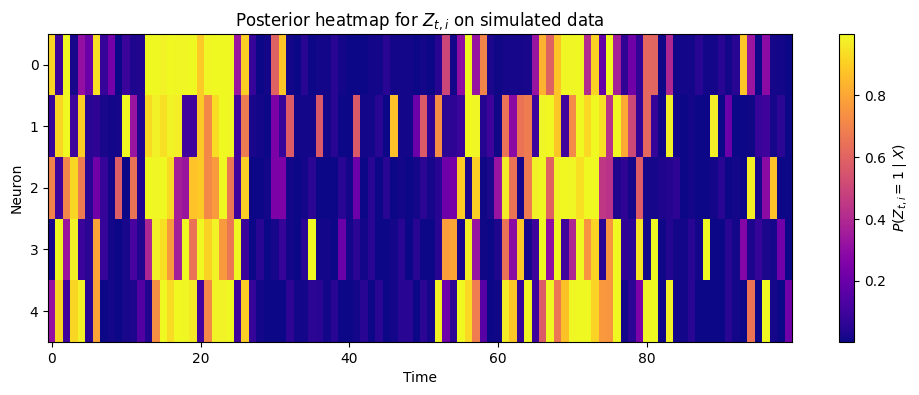

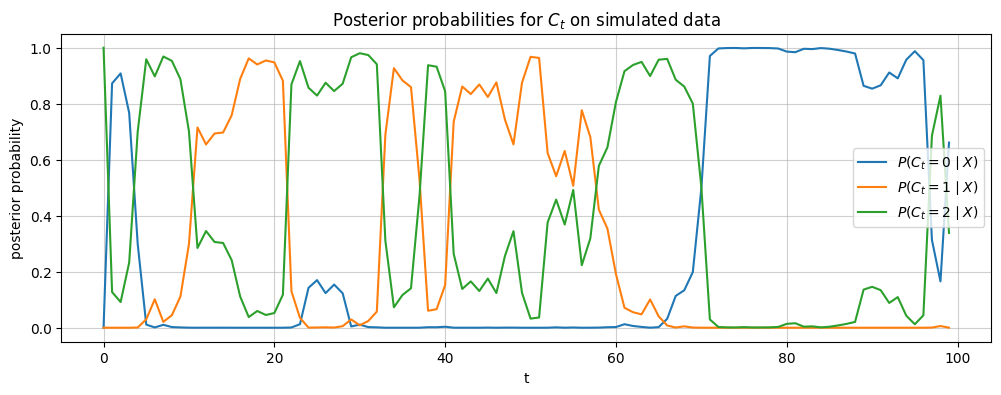

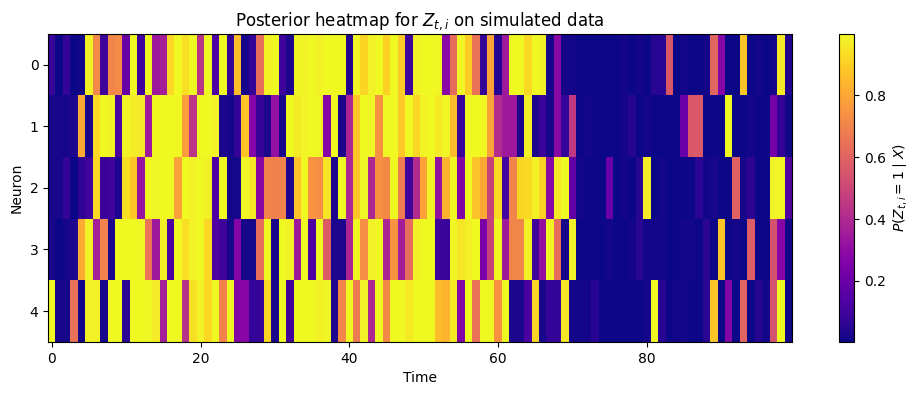

In [13]:
for i in read_data:
    res = hmm_pipeline(i, alpha_val, beta_val, small_gamma_val, lambda_0, lambda_1)
    plot_c_posterior(res)
    plot_heatmap_z_posterior(res)

In [14]:
est = learn_all_params_from_known_data(X_sim, C_true, Z_true)
est

{'alpha_hat': np.float64(0.8964912280701754),
 'beta_hat': 0.11627906976744186,
 'gamma_hat': 0.07142857142857142,
 'lambda0_hat': np.float64(0.9792332268370607),
 'lambda1_hat': np.float64(4.842245989304812)}

In [15]:
all_estimates = []

for seed in range(100):
    C_true, Z_true, X_sim = simulate_hmm(
        big_T,
        n,
        alpha_val,
        beta_val,
        small_gamma_val,
        lambda_0,
        lambda_1,
        seed
    )

    est = learn_all_params_from_known_data(X_sim, C_true, Z_true)
    all_estimates.append(est)

In [16]:
keys = ["alpha_hat", "beta_hat", "gamma_hat", "lambda0_hat", "lambda1_hat"]

for key in keys:
    vals = np.array([d[key] for d in all_estimates])
    print(
        f"{key} mean = {vals.mean():.4f} "
        f"std = {vals.std():.4f} "
        f"min = {vals.min():.4f} "
        f"max = {vals.max():.4f}"
    )

alpha_hat mean = 0.9006 std = 0.0140 min = 0.8714 max = 0.9462
beta_hat mean = 0.2009 std = 0.0655 min = 0.0732 max = 0.4167
gamma_hat mean = 0.1082 std = 0.0371 min = 0.0263 max = 0.2143
lambda0_hat mean = 1.0038 std = 0.0450 min = 0.8815 max = 1.1577
lambda1_hat mean = 5.0123 std = 0.1024 min = 4.8225 max = 5.3184


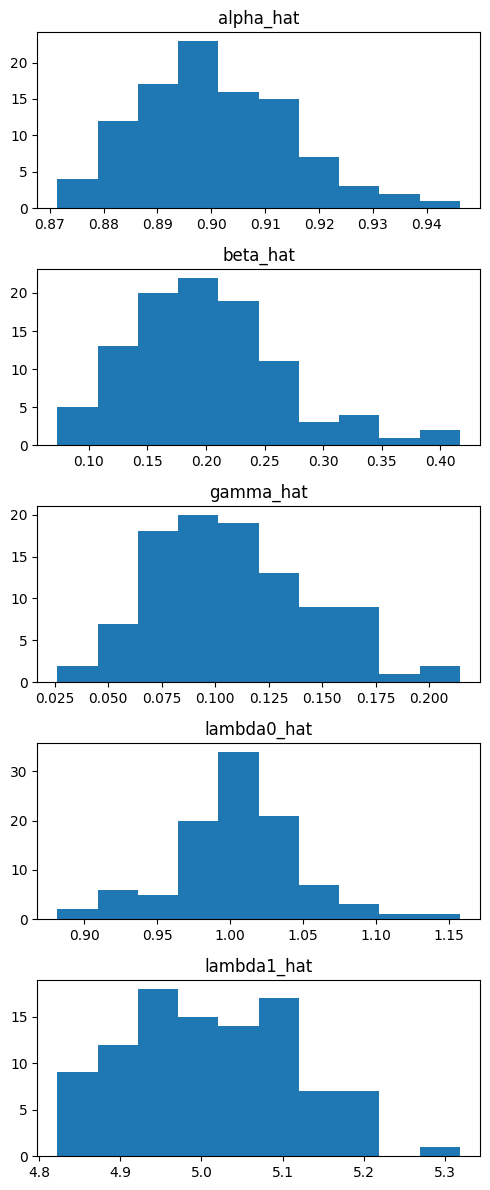

In [17]:
fig, axes = plt.subplots(5, 1, figsize=(5, 12))

for ax, key in zip(axes, keys):
    vals = np.array([d[key] for d in all_estimates])
    ax.hist(vals)
    ax.set_title(key)
plt.tight_layout()
plt.show()

In [18]:
C_true, Z_true, X_sim = simulate_hmm(big_T, n, alpha_val, beta_val, small_gamma_val, lambda_0, lambda_1, seed=123)

em_res = hard_assigment_EM(X_sim)


print(em_res["alpha_hat"])
print(em_res["beta_hat"])
print(em_res["gamma_hat"])
print(em_res["lambda0_hat"])
print(em_res["lambda1_hat"])

We wont change much more, and have converged at iteration 4.
0.95
0.11363636363636363
0.07272727272727272
0.9738461538461538
5.117142857142857


In [ ]:
all_results = []

for i in range(len(all_data)):
    res = hard_assigment_EM(read_data[i])
    all_results.append(res)

We wont change much more, and have converged at iteration 14.
We wont change much more, and have converged at iteration 4.
We wont change much more, and have converged at iteration 2.
We wont change much more, and have converged at iteration 4.
We wont change much more, and have converged at iteration 8.
We wont change much more, and have converged at iteration 13.
We wont change much more, and have converged at iteration 11.
We wont change much more, and have converged at iteration 5.
We wont change much more, and have converged at iteration 13.
We wont change much more, and have converged at iteration 7.


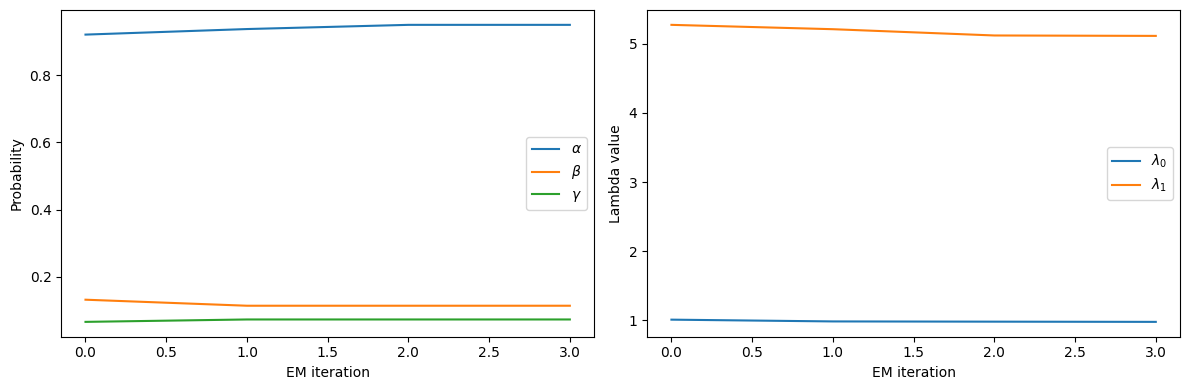

In [21]:
plot_convergence(em_res)

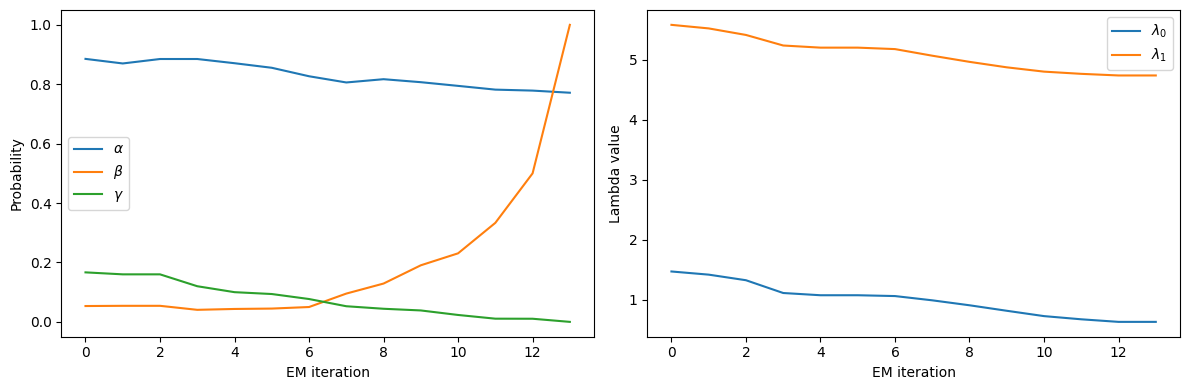

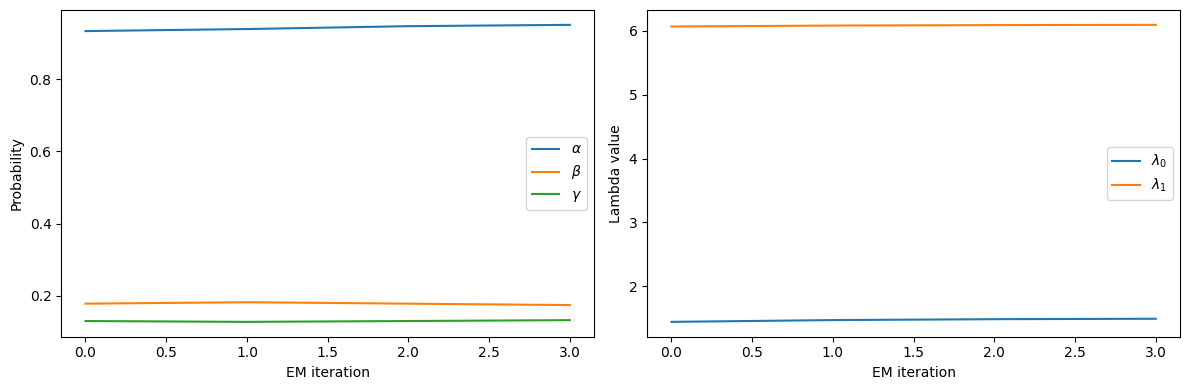

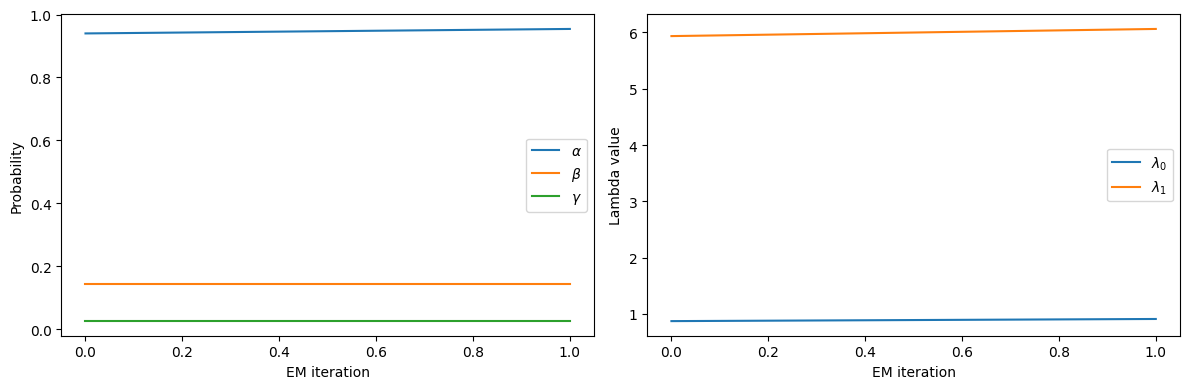

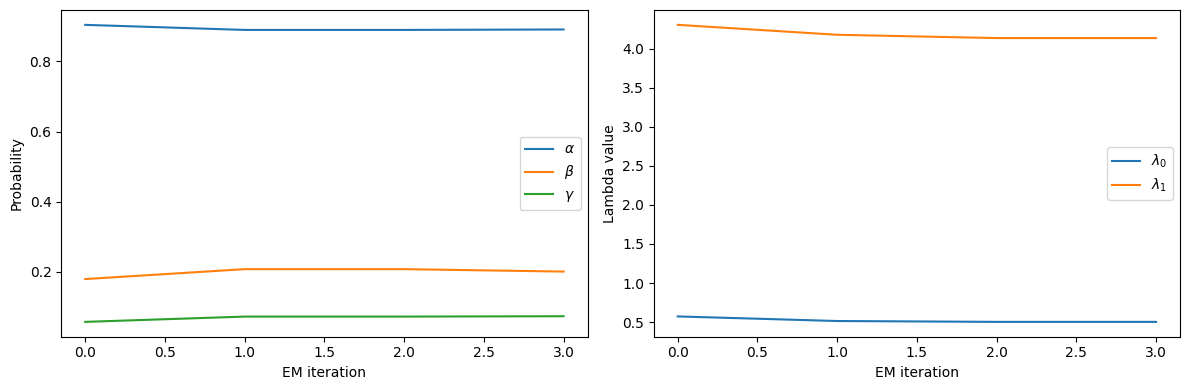

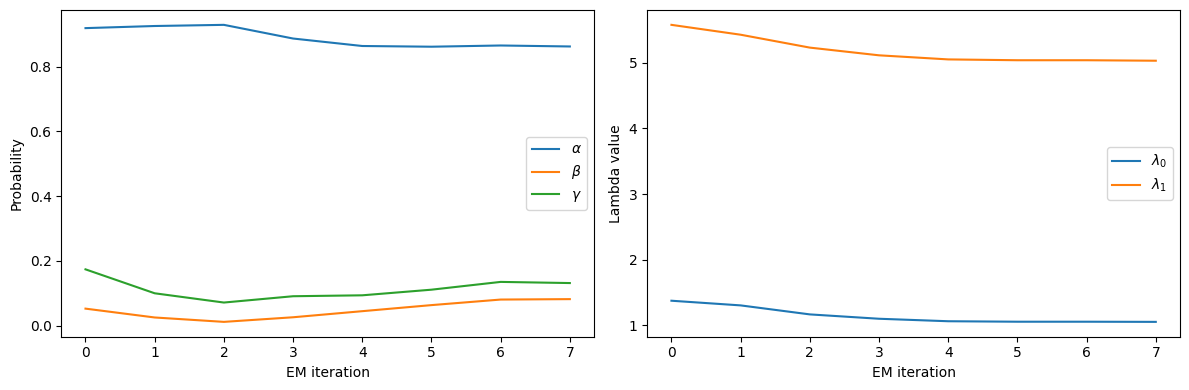

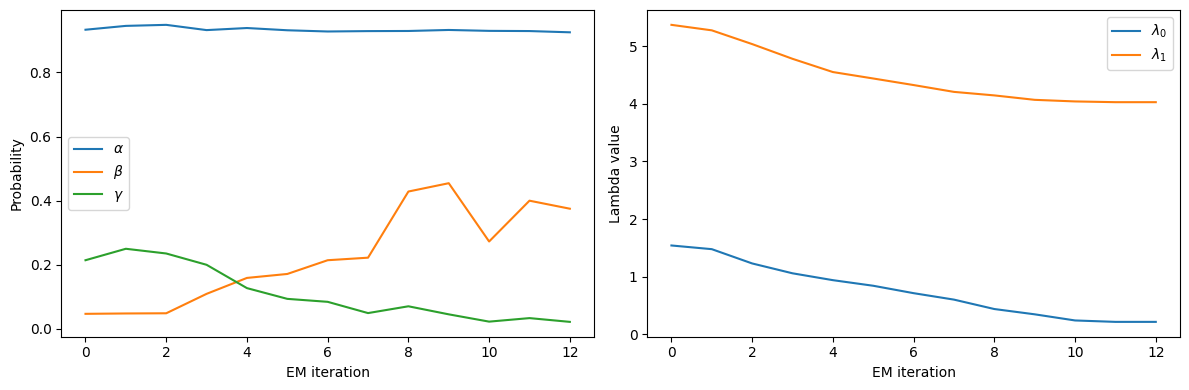

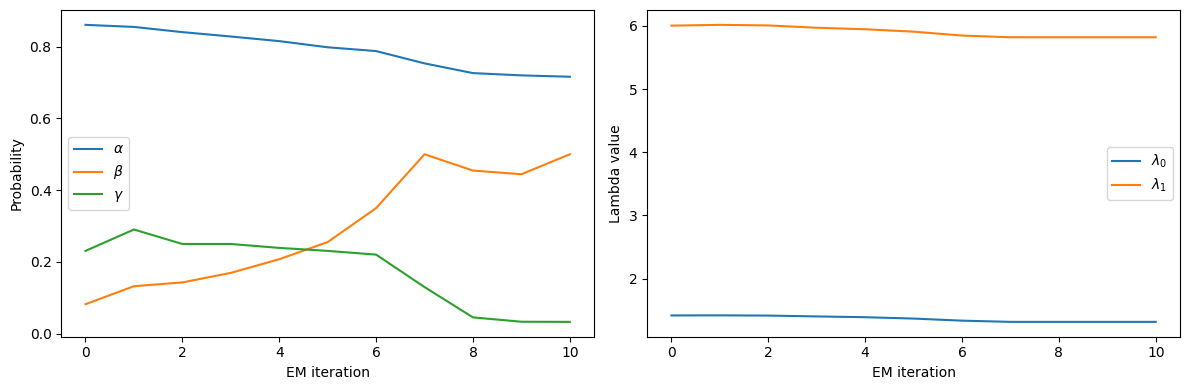

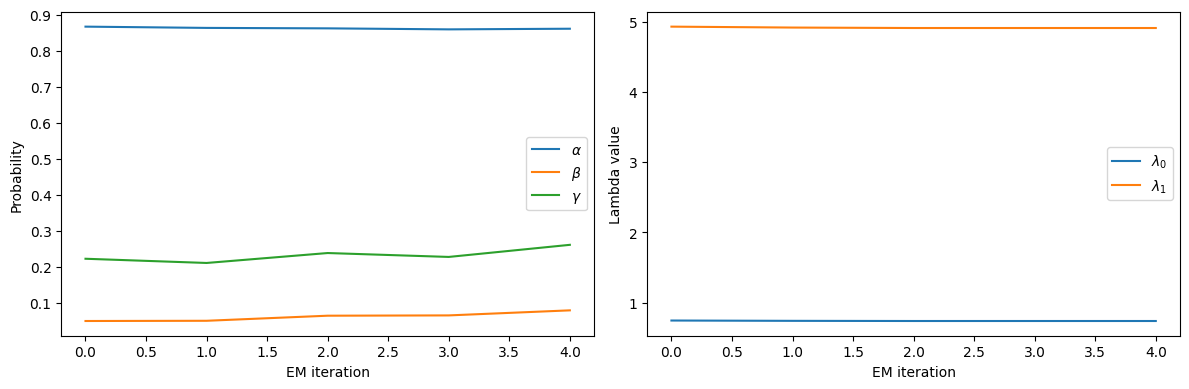

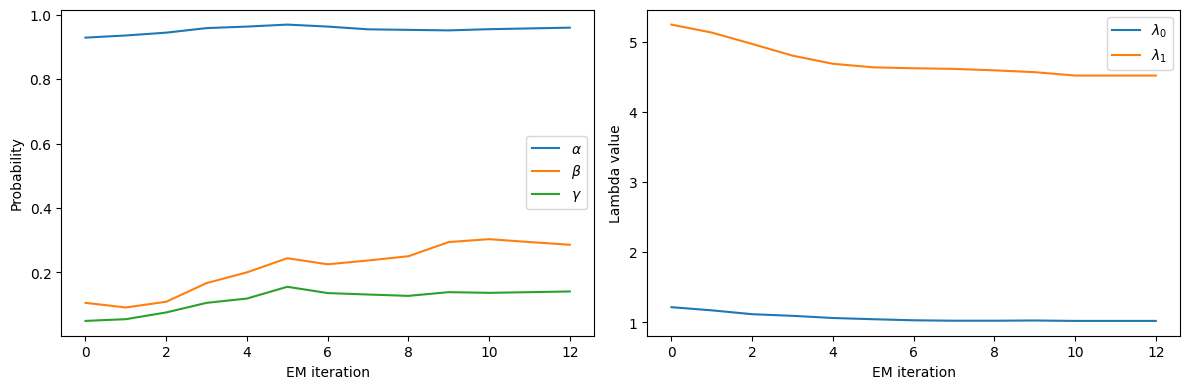

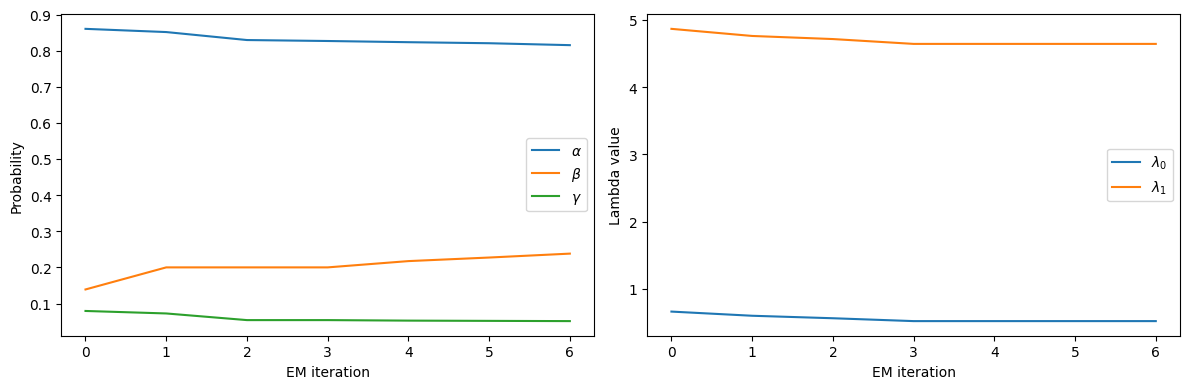

In [22]:
for i in all_results:
    plot_convergence(i)